# **Problem Statement : Explore sales data to uncover patterns in customer behavior and identify ways to increase revenue and optimize business decisions**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('amazon_sales_dataset.csv')

In [5]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [6]:
df.shape

(50000, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [8]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [9]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


Revenue by Category

In [10]:
revenue_category = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).reset_index()
display(revenue_category)

,product_category,total_revenue
0,Beauty,5550624.97
1,Books,5484863.03
2,Fashion,5480123.34
3,Home & Kitchen,5473132.55
4,Electronics,5470594.03
5,Sports,5407235.82


“Beauty category contributes highest revenue → key business driver”

Top Performing Products

In [11]:
top_10_products = df.groupby('product_id')['total_revenue'].sum().nlargest(10).reset_index().sort_values('total_revenue',ascending=False)
display(top_10_products)

,product_id,total_revenue
0,1931,18885.83
1,1087,18531.52
2,1328,18306.73
3,3537,18071.02
4,2837,17855.07
5,1266,17819.13
6,4386,17806.08
7,4264,17803.51
8,3700,17619.14
9,3377,17201.38


How concentrated is revenue across products?

In [12]:
total_revenue = df['total_revenue'].sum()

top10_revenue = df.groupby('product_id')['total_revenue'].sum().nlargest(10).sum()

contribution = (top10_revenue / total_revenue) * 100

contribution

np.float64(0.5473628356370317)

Do higher-rated products sell more?

In [13]:
df['rating_category'] = pd.cut(df['rating'], bins=[0, 4.5, 5], labels=['Low','High'])
rating_quantity = df.groupby('rating_category')['quantity_sold'].sum().reset_index()
display(rating_quantity)

,rating_category,quantity_sold
0,Low,133434
1,High,16536


Are low-priced products selling in higher quantities compared to expensive ones?

In [14]:
df['price_category'] = pd.cut(
    df['discounted_price'],
    bins=[0, 200, 450, np.inf],
    labels=['Low', 'Medium', 'High']
)
price_analysis = df.groupby('price_category').agg({
    'quantity_sold': 'mean',
    'total_revenue': 'mean'
}).reset_index()

display(price_analysis)

,price_category,quantity_sold,total_revenue
0,Low,2.995115,305.356003
1,Medium,3.002927,938.299859
2,High,3.006421,1414.092857


Do discounts increase sales quantity?

In [15]:
df['discount_category'] = pd.cut(
    df['discount_percent'],
    bins=[-1, 0, 15, 30],
    labels=['No Discount', 'Low Discount', 'High Discount'],
    right=True
)
discount_analysis = df.groupby('discount_category').agg({
    'quantity_sold': 'mean',
    'total_revenue': 'mean'
}).reset_index()
display(discount_analysis)

,discount_category,quantity_sold,total_revenue
0,No Discount,2.986490,749.033022
1,Low Discount,2.999562,686.582581
2,High Discount,3.005516,568.124245


Do people prefer highly rated products?

In [16]:
df['rating_category'] = pd.cut(
    df['rating'],
    bins=[0, 3.5, 4.5, 5],
    labels=['Low', 'Medium', 'High']
)
rating_analysis = df.groupby('rating_category').agg({
    'quantity_sold': 'mean',
    'total_revenue': 'mean'
}).reset_index()

display(rating_analysis)

,rating_category,quantity_sold,total_revenue
0,Low,3.001160,655.136230
1,Medium,2.997774,663.014190
2,High,2.992941,657.066617


How does sales volume vary across regions?

In [23]:
region_analysis = df.groupby('customer_region').agg({
    'total_revenue': 'sum',
    'quantity_sold': 'mean'
}).reset_index().sort_values('total_revenue', ascending=False)
display(region_analysis)

,customer_region,total_revenue,quantity_sold
2,Middle East,8301844.50,3.014314
3,North America,8277217.84,2.998642
0,Asia,8175199.83,2.988983
1,Europe,8112311.57,2.995663


Which payment methods are most commonly used?

In [26]:
payment_analysis = df.groupby('payment_method').agg({
    'total_revenue': 'sum',
    'quantity_sold': 'mean'
}).reset_index().sort_values('total_revenue', ascending=False)
display(payment_analysis)

,payment_method,total_revenue,quantity_sold
4,Wallet,6678638.47,3.000396
3,UPI,6579441.44,2.980254
0,Cash on Delivery,6546386.94,3.010074
1,Credit Card,6540087.16,3.015240
2,Debit Card,6522019.73,2.991384


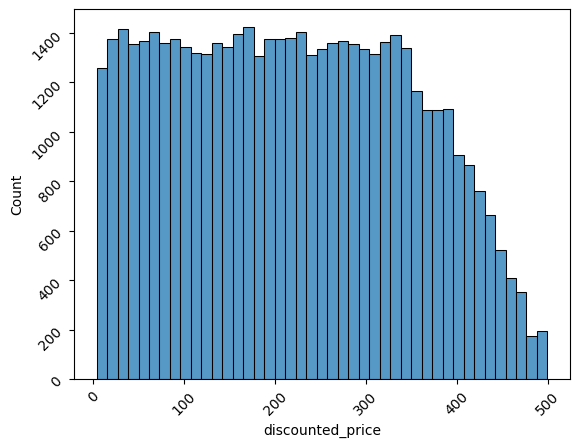

In [18]:
sns.histplot(df['discounted_price'])
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

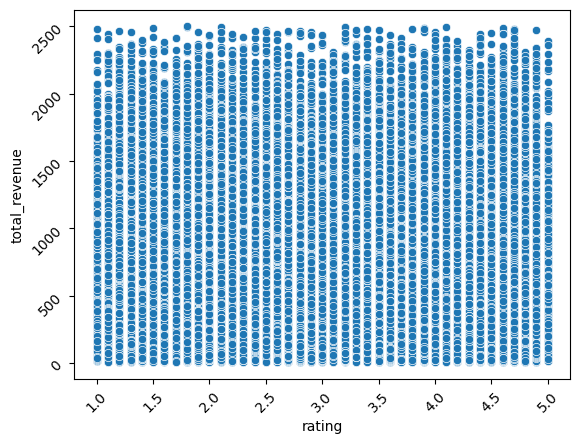

In [19]:
sns.scatterplot(x='rating', y='total_revenue', data=df)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

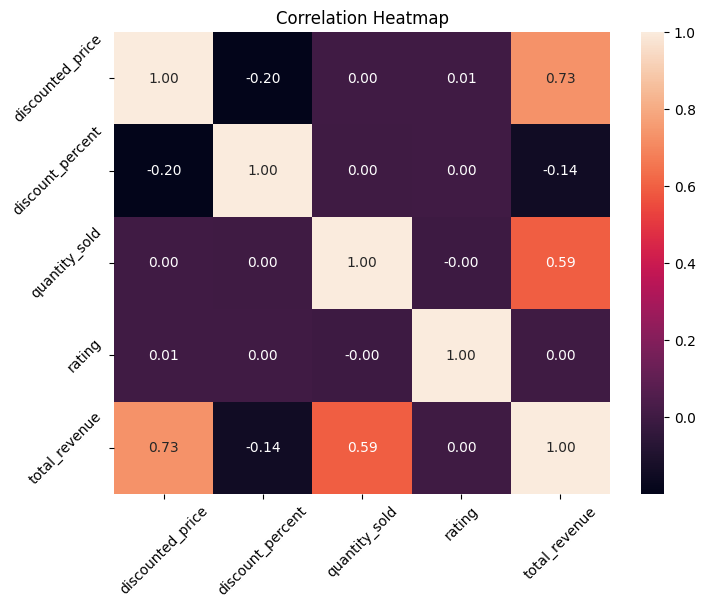

In [20]:
# Select only numeric columns
corr_matrix = df[['discounted_price','discount_percent','quantity_sold','rating','total_revenue']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.title("Correlation Heatmap")
plt.show()

Rating vs Revenue

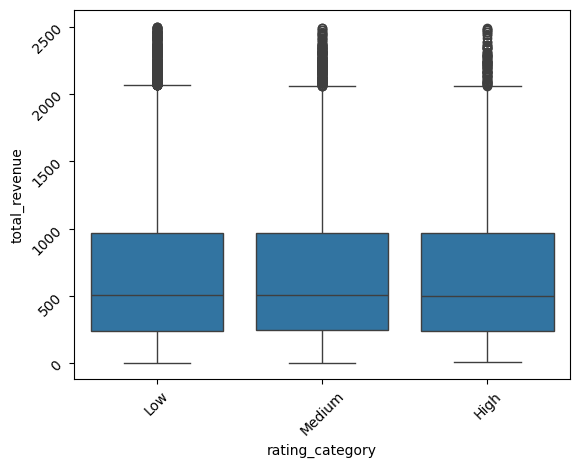

In [21]:
sns.boxplot(x='rating_category', y='total_revenue', data=df)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

# **Key Findings:**

Revenue is moderately concentrated, with top products contributing ~55% of total revenue

Pricing is the strongest driver of revenue, while demand remains consistent across price ranges

Higher-priced products generate significantly more revenue without reducing sales volume

Discounts slightly increase sales quantity but significantly reduce overall revenue

Ratings have limited impact on revenue, with no strong difference in distribution across categories

Customers are not highly price-sensitive, indicating value-driven purchasing behavior

# **Business Recommendations**

Focus on promoting higher-priced products, as they drive significantly more revenue without reducing demand

Avoid aggressive discounting; use targeted or limited discounts to prevent revenue loss

Improve visibility and positioning of mid-performing products to increase their contribution

Leverage highly rated products in marketing to build customer trust and boost conversions

Optimize product pricing strategy instead of relying heavily on discounts

Enhance product descriptions, branding, and perceived value to influence purchase decisions

Diversify revenue sources to reduce dependency on top-performing products

Identify and scale high-potential products with consistent performance

Analyze customer segments (region, behavior) to personalize offerings and improve sales

Continuously monitor pricing, discount impact, and product performance for data-driven decision-making